In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [2]:
training_cells = ["B0005","B0006","B0007"]
testing_cells = ["B0018"]
processed_fldr = "../data/processed/"
training_fldr = "../data/training/"
testing_fldr = "../data/testing/"

In [3]:
def degradation_class(soh):
    class_no = 0
    if soh >= 90:
        class_no = 0 # Healthy
    elif soh < 90 and soh >= 85:
        class_no = 1 # Early Degradation
    elif soh < 85 and soh >= 80:
        class_no = 2 # advance degradation
    else:
        class_no = 3 # Critical
    
    return class_no

In [4]:
# list of features
volt_start = []
volt_end = []
volt_std = []
temp_max = []
temp_min = []
temp_avg = []
temp_std = []
curr_max = []
curr_min = []
curr_avg = []
curr_std = []
time_to_0soc = []
time_to_10soc = []
time_to_25soc = []
time_to_40soc = []
time_to_50soc = []
degradation = []


In [5]:
training_filename = "diagnostic_data"
testing_filename = "diagnositc_testData"

In [6]:
file_count = 0
for fldr in os.listdir(processed_fldr):
    if fldr in training_cells:
        dchg_fldr = processed_fldr + fldr + "/discharge/"
        no_of_files = len(os.listdir(dchg_fldr))
        initial_capacity = 0
        print(f"folder {dchg_fldr} with no of files {no_of_files}")
        for i in range(0,no_of_files):
            file_count += 1
            file = f"dchgCycle_{i}.csv"
            filename = dchg_fldr + file
            df = pd.read_csv(filename)
            
            time = df["time"].values
            voltage = df["voltage"].values
            current = df["current"].values
            temperature = df["temperature"].values
            soc = df["soc"].values
            cap = df["capacity"].values[0]

            if i == 0:
                initial_capacity = cap
                soh = (cap/initial_capacity)*100
            else:
                soh = (cap/initial_capacity)*100

            volt_start.append(voltage[0])
            volt_end.append(voltage[-1])
            volt_std.append(np.std(voltage))
            temp_max.append(np.max(temperature))
            temp_min.append(np.min(temperature))
            temp_avg.append(np.average(temperature))
            temp_std.append(np.std(temperature))
            curr_max.append(np.min(current))    # discharge current is negative
            curr_min.append(np.max(current))    # discharge current is negative
            curr_avg.append(np.average(current))
            curr_std.append(np.std(current))
            degradation.append(degradation_class(soh))

            soc_time_fnc = interp1d(soc, time)

            time_to_0soc.append(soc_time_fnc(0))
            time_to_10soc.append(soc_time_fnc(0.1))
            time_to_25soc.append(soc_time_fnc(0.25))
            time_to_40soc.append(soc_time_fnc(0.4))
            time_to_50soc.append(soc_time_fnc(0.5))


diag_df = pd.DataFrame({
    "volt_start": volt_start, 
    "volt_end": volt_end, 
    "volt_std": volt_std, 
    "temp_max": temp_max, 
    "temp_min": temp_min,  
    "temp_avg": temp_avg, 
    "temp_std": temp_std, 
    "curr_max": curr_max, 
    "curr_min": curr_min, 
    "curr_avg": curr_avg, 
    "curr_std": curr_std, 
    "time_to_0soc": np.array(time_to_0soc).astype(np.float64), 
    "time_to_10soc": np.array(time_to_10soc).astype(np.float64), 
    "time_to_25soc": np.array(time_to_25soc).astype(np.float64), 
    "time_to_40soc": np.array(time_to_40soc).astype(np.float64), 
    "time_to_50soc": np.array(time_to_50soc).astype(np.float64),
    "degradation": degradation})   

diag_df.to_csv(training_fldr + training_filename + ".csv", index=False)  

print(file_count)

folder ../data/processed/B0005/discharge/ with no of files 168
folder ../data/processed/B0006/discharge/ with no of files 168
folder ../data/processed/B0007/discharge/ with no of files 168
504


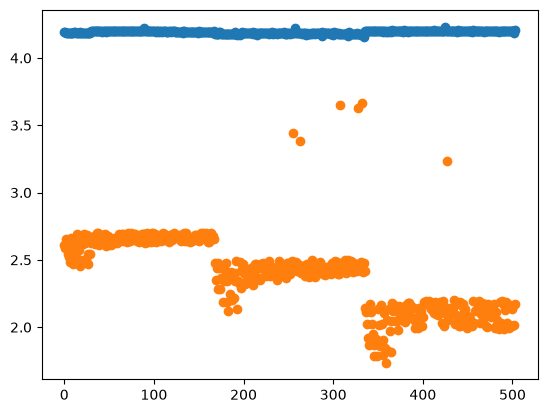

In [7]:

plt.scatter(range(len(volt_start)),volt_start)
plt.scatter(range(len(volt_end)),volt_end)

In [8]:
diag_df.head()

,volt_start,volt_end,volt_std,temp_max,temp_min,temp_avg,temp_std,curr_max,curr_min,curr_avg,curr_std,time_to_0soc,time_to_10soc,time_to_25soc,time_to_40soc,time_to_50soc,degradation
0,4.191492,2.612467,0.221937,38.904112,24.325993,32.196748,3.385642,-2.018015,-0.001478,-1.990294,0.210638,3346.937,2988.798734,2494.925688,1993.781164,1660.722284,0
1,4.189773,2.587209,0.220868,38.934590,24.685948,32.351774,3.323879,-2.016821,0.000021,-1.990079,0.211502,3328.828,2970.932149,2476.991823,1981.776433,1651.256208,0
2,4.188187,2.651917,0.215820,38.743649,24.734266,32.277595,3.283721,-2.016574,-0.001754,-1.989882,0.211939,3309.422,2955.190865,2462.807846,1970.217046,1642.873262,0
3,4.188461,2.592948,0.219867,38.672511,24.652244,32.151764,3.276088,-2.015936,0.000234,-1.989586,0.211961,3309.719,2953.807410,2462.541808,1969.481263,1641.440990,0
4,4.188299,2.547420,0.222766,38.558828,24.518700,32.014608,3.280730,-2.017426,0.001701,-1.990128,0.211820,3307.688,2955.855436,2462.511873,1968.414178,1640.533634,0


In [9]:
diag_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   volt_start     504 non-null    float64
 1   volt_end       504 non-null    float64
 2   volt_std       504 non-null    float64
 3   temp_max       504 non-null    float64
 4   temp_min       504 non-null    float64
 5   temp_avg       504 non-null    float64
 6   temp_std       504 non-null    float64
 7   curr_max       504 non-null    float64
 8   curr_min       504 non-null    float64
 9   curr_avg       504 non-null    float64
 10  curr_std       504 non-null    float64
 11  time_to_0soc   504 non-null    float64
 12  time_to_10soc  504 non-null    float64
 13  time_to_25soc  504 non-null    float64
 14  time_to_40soc  504 non-null    float64
 15  time_to_50soc  504 non-null    float64
 16  degradation    504 non-null    int64  
dtypes: float64(16), int64(1)
memory usage: 67.1 KB


In [10]:
diag_df.describe()

,volt_start,volt_end,volt_std,temp_max,temp_min,temp_avg,temp_std,curr_max,curr_min,curr_avg,curr_std,time_to_0soc,time_to_10soc,time_to_25soc,time_to_40soc,time_to_50soc,degradation
count,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000,504.000000
mean,4.192809,2.394762,0.246124,39.939722,24.118333,32.235743,3.789234,-2.009343,-0.000414,-1.986709,0.177658,2887.487192,2567.421550,2139.616039,1711.737910,1426.380826,1.686508
std,0.009325,0.273672,0.016781,1.155795,0.472573,0.619841,0.366542,0.010708,0.001670,0.024388,0.050243,380.640187,339.385266,282.832727,226.225431,188.513718,1.315505
min,4.157545,1.737030,0.210613,36.939408,22.969923,30.606693,3.103623,-2.029098,-0.006279,-2.001462,0.145865,2108.406000,1860.103448,1548.392307,1238.477830,1032.369606,0.000000
25%,4.183841,2.156048,0.234566,39.034382,23.800210,31.872829,3.464359,-2.016820,-0.001489,-1.997437,0.158984,2597.230500,2307.050132,1920.608937,1537.742202,1281.604971,0.000000
50%,4.196497,2.430207,0.247371,40.233286,24.062902,32.207960,3.817462,-2.014815,-0.000582,-1.994027,0.167318,2848.922500,2530.827807,2109.850652,1687.717751,1405.951869,2.000000
75%,4.199805,2.639299,0.256587,40.853734,24.376440,32.680557,4.074780,-1.994676,0.000575,-1.977051,0.179239,3247.300750,2895.631446,2414.656848,1931.179174,1610.000026,3.000000
max,4.233146,3.663027,0.281175,42.083729,26.647374,34.125027,4.768481,-1.992201,0.005934,-1.673230,0.749985,3690.234000,3279.369128,2733.002353,2184.464415,1821.691176,3.000000


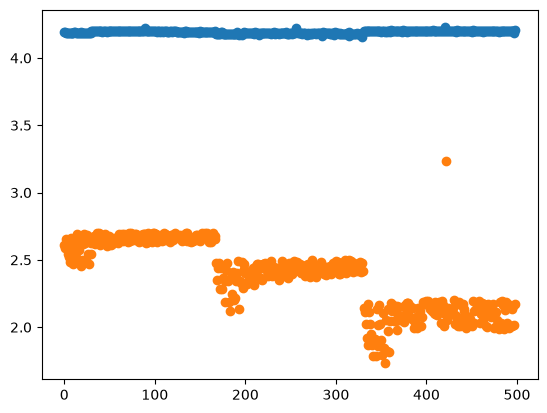

In [11]:
# Removing outlier based on volt_end

Q1 = diag_df['volt_end'].quantile(0.25)
Q3 = diag_df["volt_end"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR

diag_df = diag_df[(diag_df['volt_end'] >= lower_limit) & (diag_df["volt_end"] <= upper_limit)]

diag_df.to_csv(training_fldr + training_filename + ".csv", index=False) 

plt.scatter(range(len(diag_df['volt_start'])),diag_df['volt_start'])
plt.scatter(range(len(diag_df['volt_end'])),diag_df['volt_end'])

In [12]:
# list of features
volt_start = []
volt_end = []
volt_std = []
temp_max = []
temp_min = []
temp_avg = []
temp_std = []
curr_max = []
curr_min = []
curr_avg = []
curr_std = []
time_to_0soc = []
time_to_10soc = []
time_to_25soc = []
time_to_40soc = []
time_to_50soc = []
degradation = []

In [13]:
file_count = 0
for fldr in os.listdir(processed_fldr):
    if fldr in testing_cells:
        dchg_fldr = processed_fldr + fldr + "/discharge/"
        no_of_files = len(os.listdir(dchg_fldr))
        initial_capacity = 0
        print(f"folder {dchg_fldr} with no of files {no_of_files}")
        for i in range(0,no_of_files):
            file_count += 1
            file = f"dchgCycle_{i}.csv"
            filename = dchg_fldr + file
            df = pd.read_csv(filename)
            
            time = df["time"].values
            voltage = df["voltage"].values
            current = df["current"].values
            temperature = df["temperature"].values
            soc = df["soc"].values
            cap = df["capacity"].values[0]

            if i == 0:
                initial_capacity = cap
                soh = (cap/initial_capacity)*100
            else:
                soh = (cap/initial_capacity)*100
            
            volt_start.append(voltage[0])
            volt_end.append(voltage[-1])
            volt_std.append(np.std(voltage))
            temp_max.append(np.max(temperature))
            temp_min.append(np.min(temperature))
            temp_avg.append(np.average(temperature))
            temp_std.append(np.std(temperature))
            curr_max.append(np.min(current))    # discharge current is negative
            curr_min.append(np.max(current))    # discharge current is negative
            curr_avg.append(np.average(current))
            curr_std.append(np.std(current))
            degradation.append(degradation_class(soh))

            soc_time_fnc = interp1d(soc, time)

            time_to_0soc.append(soc_time_fnc(0))
            time_to_10soc.append(soc_time_fnc(0.1))
            time_to_25soc.append(soc_time_fnc(0.25))
            time_to_40soc.append(soc_time_fnc(0.4))
            time_to_50soc.append(soc_time_fnc(0.5))


diag_test_df = pd.DataFrame({
    "volt_start": volt_start, 
    "volt_end": volt_end, 
    "volt_std": volt_std, 
    "temp_max": temp_max, 
    "temp_min": temp_min,  
    "temp_avg": temp_avg, 
    "temp_std": temp_std, 
    "curr_max": curr_max, 
    "curr_min": curr_min, 
    "curr_avg": curr_avg, 
    "curr_std": curr_std, 
    "time_to_0soc": np.array(time_to_0soc).astype(np.float64), 
    "time_to_10soc": np.array(time_to_10soc).astype(np.float64), 
    "time_to_25soc": np.array(time_to_25soc).astype(np.float64), 
    "time_to_40soc": np.array(time_to_40soc).astype(np.float64), 
    "time_to_50soc": np.array(time_to_50soc).astype(np.float64),
    "degradation_class": degradation})   

diag_test_df.to_csv(testing_fldr + testing_filename + ".csv", index=False)  

print(file_count)

folder ../data/processed/B0018/discharge/ with no of files 132
132


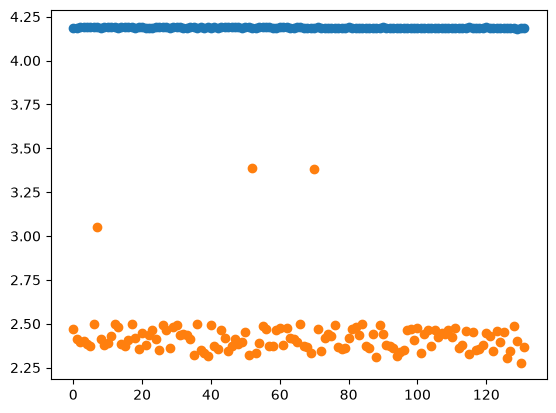

In [14]:
plt.scatter(range(len(volt_start)),volt_start)
plt.scatter(range(len(volt_end)),volt_end)

In [15]:
diag_test_df.describe()

,volt_start,volt_end,volt_std,temp_max,temp_min,temp_avg,temp_std,curr_max,curr_min,curr_avg,curr_std,time_to_0soc,time_to_10soc,time_to_25soc,time_to_40soc,time_to_50soc,degradation_class
count,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000
mean,4.187754,2.430441,0.246022,37.578733,23.281296,30.646904,3.456061,-2.013639,0.001662,-1.989084,0.190043,2825.884394,2512.237937,2093.891293,1675.067428,1395.982823,1.689394
std,0.002147,0.141885,0.015739,0.571552,0.437962,0.409677,0.220496,0.002342,0.002518,0.017672,0.047802,275.017401,250.010563,208.331110,166.765743,138.816334,1.296693
min,4.181407,2.278634,0.217948,36.270543,22.350256,29.804108,3.092217,-2.026719,-0.003054,-1.997846,0.149811,2447.687000,2162.146659,1801.887603,1440.855572,1202.108246,0.000000
25%,4.186278,2.370280,0.231267,37.216697,23.030991,30.363379,3.243239,-2.013648,0.000365,-1.993933,0.170020,2566.090500,2282.122802,1902.975285,1522.160922,1268.002806,0.000000
50%,4.187754,2.415305,0.246619,37.608555,23.254435,30.650634,3.441601,-2.013046,0.001413,-1.991113,0.185932,2785.539500,2471.696197,2058.080482,1645.853779,1373.103479,2.000000
75%,4.189395,2.464485,0.259779,38.005431,23.500959,30.902241,3.657436,-2.012561,0.002438,-1.988549,0.201849,3046.980500,2716.393362,2264.536436,1812.626565,1509.070499,3.000000
max,4.193543,3.387495,0.273008,38.675627,24.695287,31.857805,3.827341,-2.011350,0.014306,-1.844863,0.548685,3357.531000,2991.426631,2493.944123,1993.609575,1661.113647,3.000000


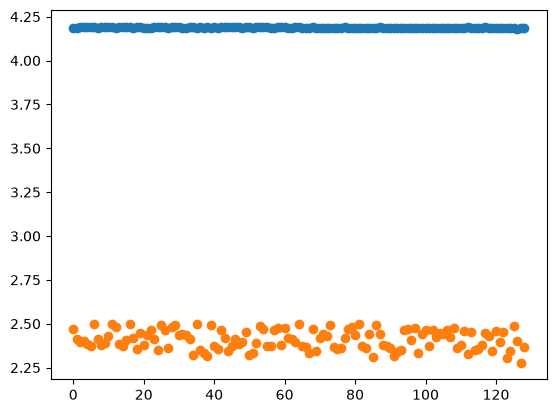

In [16]:
# Removing outlier based on volt_end

Q1 = diag_test_df['volt_end'].quantile(0.25)
Q3 = diag_test_df["volt_end"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR

diag_test_df = diag_test_df[(diag_test_df['volt_end'] >= lower_limit) & (diag_test_df["volt_end"] <= upper_limit)]

diag_test_df.to_csv(testing_fldr + testing_filename + ".csv", index=False) 

plt.scatter(range(len(diag_test_df['volt_start'])),diag_test_df['volt_start'])
plt.scatter(range(len(diag_test_df['volt_end'])),diag_test_df['volt_end'])